In [11]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime import SamplerV2 as Sampler
from sklearn.model_selection import train_test_split

In [39]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Dataset
n          = 1000    # Number of generated points
TEST_SIZE  = 0.2    # Fraction used for test set
SEED       = 1      # Random seed (data split & optimizer init)
N_DIM      = 6   # Features dimension

# Optimization
MAXITER    = 200     # minimizer max iterations
optimizer = COBYLA(maxiter=MAXITER) 

# Noise 
USE_NOISE = False 
NOISE_RATE = 0.02
# ──────────────────────────────────────────────────────────────────────────────
REUPLOAD_SHOTS = 2048


In [40]:
if USE_NOISE:
    nm = NoiseModel()
    err1 = depolarizing_error(NOISE_RATE, 1)
    nm.add_all_qubit_quantum_error(err1, ['u', 'h', 'ry', 'rz'])
    err2 = depolarizing_error(NOISE_RATE * 5, 2)
    nm.add_all_qubit_quantum_error(err2, ['cx'])
    backend = AerSimulator(noise_model=nm, method="density_matrix")
    sampler = Sampler(backend)
else:
    sampler = Sampler(AerSimulator())

-> Mode IDÉAL


In [41]:
def generate_nsphere_data(n_samples, n_dim, radius=None, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-1, 1, (n_samples, n_dim))
    if radius is None:
        radius = np.sqrt(n_dim / 3)
    dist_sq = np.sum(X**2, axis=1)
    y = (dist_sq >= radius**2).astype(int)
    return X, y, radius

In [42]:
X, y, R = generate_nsphere_data(n_samples=n, n_dim=N_DIM, seed=SEED)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)
print(X_train.shape, y_train.shape)

(800, 6) (800,)


## VQC

In [43]:
iteration = 0
def callback(*_):
    global iteration
    iteration += 1
    print(f"Iteration {iteration}")

In [44]:
def interpret_q0(x):
    "Lis la parité du premier qubit"
    return x%2

In [45]:
feature_map = zz_feature_map(feature_dimension=N_DIM, reps=2, entanglement='linear')
ansatz = real_amplitudes(num_qubits=N_DIM, reps=2)

vqc = VQC(feature_map=feature_map, ansatz=ansatz, optimizer=optimizer, callback=callback, interpret=interpret_q0, sampler=sampler)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


## Training

In [46]:
print(f"Entraînement sur une {N_DIM}-sphère...")
vqc.fit(X_train, y_train )

Entraînement sur une 6-sphère...


## VQC Results 

In [47]:
accuracy = vqc.score(X_test, y_test)
y_pred = vqc.predict(X_test)
print(f"Précision sur le test: {accuracy*100} %")

Précision sur le test: 55.50000000000001 %


### Visualisation si dim=2 ou 3 

In [ ]:
def plot_2d() : 
    pred1 = X_test[y_pred == 1]
    pred0 = X_test[y_pred == 0]

    plt.scatter(pred0[:,0],pred0[:,1], color = 'red', label='pred0')
    plt.scatter(pred1[:,0],pred1[:,1], color = 'blue', label='pred1')


    circle_rad = np.sqrt(N_DIM/3) # rayon par défaut, à modifier si le rayon est changé
    circle = plt.Circle((0, 0), circle_rad, color='black', fill=False, 
                        linestyle='--', linewidth=2, label='Frontière réelle')
    plt.gca().add_artist(circle)

    # Configuration du graphique
    plt.title(f"Visualisation des performances ({accuracy*100}%)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)
    plt.legend(loc='upper right')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.show()
    
def plot_3d() :
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Masques pour séparer les résultats
    pred1 = X_test[y_pred == 1]
    pred0 = X_test[y_pred == 0]

    ax.scatter(pred0[:,0],pred0[:,1],pred0[:,2], color = 'red', label='pred0')
    ax.scatter(pred1[:,0],pred1[:,1],pred1[:,2], color = 'blue', label='pred1')
    

    # Dessiner l'enveloppe de la sphère théorique (Wireframe)
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    x_sphere = R * np.outer(np.cos(u), np.sin(v))
    y_sphere = R * np.outer(np.sin(u), np.sin(v))
    z_sphere = R * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color="black", alpha=0.1, linewidths=0.5)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f"Visualisation 3D : Accuracy {accuracy*100}%")
    ax.legend()
    plt.show()

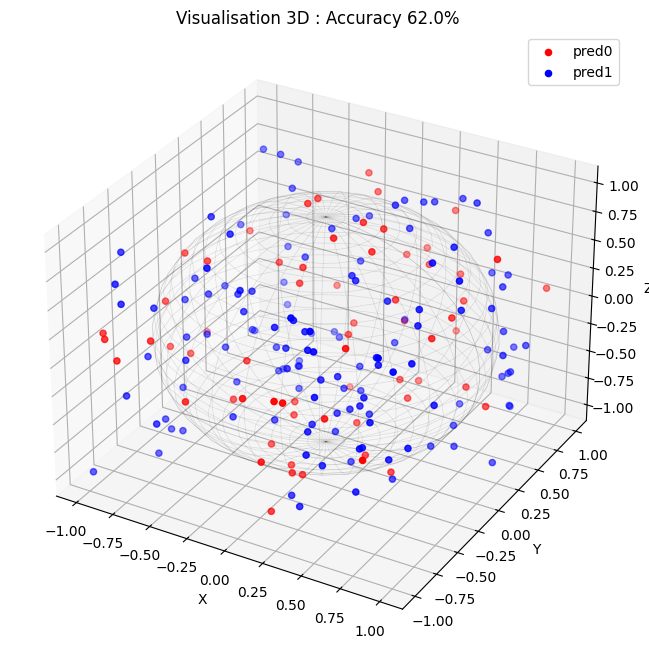

In [13]:

if N_DIM == 2 : 
    plot_2d()
    
elif N_DIM == 3 : 
    plot_3d()
    
    

## Re-uploading baseline (1 qubit, seulement pour la 3-sphère)

On garde le VQC actuel, puis on ajoute un second entraînement inspiré du notebook `circuit.ipynb`. Cette seconde partie n'est exécutée que si `N_DIM == 3`, car on veut tester l'idée qu'un seul qubit peut suffire avec du re-uploading.

In [ ]:
from scipy.optimize import minimize
from qiskit_aer import StatevectorSimulator

In [ ]:
RC_REUPLOAD = 8
MAXITER_REUPLOAD = 150
USE_REUPLOAD = (N_DIM == 3)

print(f"USE_REUPLOAD = {USE_REUPLOAD}")

USE_REUPLOAD = True


In [28]:
def U_su2_reupload(qc, theta_block, omega_block, x, qubit=0):
    """
    Une couche de type U(theta + omega * x) sur un seul qubit.
    Pour N_DIM=3, on injecte directement les 3 coordonnées.
    """
    qc.u(
        theta_block[0] + omega_block[0] * x[0],
        theta_block[1] + omega_block[1] * x[1],
        theta_block[2] + omega_block[2] * x[2],
        qubit
    )

def create_reupload_circuit(x, theta, omega, measure=False):
    qc = QuantumCircuit(1)
    for r in range(RC_REUPLOAD):
        qc.h(0)
        U_su2_reupload(qc, theta[r], omega[r], x, qubit=0)
    if measure:
        qc.measure_all()
    return qc

def get_reupload_probs_batch(circuits, shots=REUPLOAD_SHOTS):
    """
    - Si USE_NOISE = True : exécute les circuits mesurés sur AerSimulator bruité.
    - Sinon : utilise StatevectorSimulator pour obtenir les probabilités exactes.
    """
    probs = []

    if USE_NOISE:
        measured_circuits = []
        for qc in circuits:
            qc_m = qc.copy()
            if qc_m.num_clbits == 0:
                qc_m.measure_all()
            measured_circuits.append(qc_m)

        transpiled_circuits = transpile(measured_circuits, backend)
        result = backend.run(transpiled_circuits, shots=shots).result()

        for qc_t in transpiled_circuits:
            counts = result.get_counts(qc_t)
            p0 = counts.get('0', 0) / shots
            p1 = counts.get('1', 0) / shots
            probs.append((p0, p1))
    else:
        sim = StatevectorSimulator()
        for qc in circuits:
            sv = sim.run(qc).result().get_statevector()
            p0 = float(np.abs(sv[0])**2)
            p1 = float(np.abs(sv[1])**2)
            probs.append((p0, p1))

    return probs


In [ ]:
def reupload_cost_weighted(params, X, y):
    """
    Même esprit que dans circuit.ipynb :
    - theta : paramètres "de traitement"
    - omega : poids qui multiplient les features avant réinjection
    - alphas : poids de classe pour équilibrer le coût
    """
    theta = params[:3 * RC_REUPLOAD].reshape(RC_REUPLOAD, 3)
    omega = params[3 * RC_REUPLOAD:6 * RC_REUPLOAD].reshape(RC_REUPLOAD, 3)
    alphas = params[6 * RC_REUPLOAD:]  # alpha_0, alpha_1

    circuits = [create_reupload_circuit(x, theta, omega, measure=False) for x in X]
    probs = get_reupload_probs_batch(circuits)

    total_cost = 0.0
    for i, y_target in enumerate(y):
        p0, p1 = probs[i]
        y_expected = (1.0, 0.0) if y_target == 0 else (0.0, 1.0)
        weight = alphas[y_target] ** 2
        total_cost += weight * ((p0 - y_expected[0])**2 + (p1 - y_expected[1])**2)

    return 0.5 * total_cost / len(X)

def unpack_reupload_params(params):
    theta = params[:3 * RC_REUPLOAD].reshape(RC_REUPLOAD, 3)
    omega = params[3 * RC_REUPLOAD:6 * RC_REUPLOAD].reshape(RC_REUPLOAD, 3)
    alphas = params[6 * RC_REUPLOAD:]
    return theta, omega, alphas

def optimize_reupload_parameters(X, y):
    rng = np.random.default_rng(SEED)
    init = rng.uniform(-np.pi, np.pi, size=6 * RC_REUPLOAD + 2)

    reupload_cost_history = []

    def objective(params):
        cost = reupload_cost_weighted(params, X, y)
        reupload_cost_history.append(cost)
        print(f"Iteration {len(reupload_cost_history):3d} | cost = {cost:.6f}")
        return cost

    res = minimize(
        objective,
        init,
        method="COBYLA",
        options={"maxiter": MAXITER_REUPLOAD}
    )

    theta_opt, omega_opt, alphas_opt = unpack_reupload_params(res.x)
    return res, theta_opt, omega_opt, alphas_opt, reupload_cost_history

def predict_reupload_batch(X, theta, omega):
    circuits = [create_reupload_circuit(x, theta, omega, measure=False) for x in X]
    probs = get_reupload_probs_batch(circuits)
    return np.array([0 if p0 >= p1 else 1 for p0, p1 in probs])

def evaluate_binary_predictions(y_true, y_pred, positive_label=1):
    tp = np.sum((y_pred == positive_label) & (y_true == positive_label))
    fp = np.sum((y_pred == positive_label) & (y_true != positive_label))
    fn = np.sum((y_pred != positive_label) & (y_true == positive_label))
    tn = np.sum((y_pred != positive_label) & (y_true != positive_label))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    accuracy = np.mean(y_pred == y_true)

    return {
        "precision": precision,
        "accuracy": accuracy,
        "recall": recall,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
    }

def evaluate_reupload(X, y, theta, omega, positive_label=1):
    y_pred = predict_reupload_batch(X, theta, omega)
    metrics = evaluate_binary_predictions(y, y_pred, positive_label=positive_label)
    metrics["y_pred"] = y_pred
    return metrics

In [ ]:
if USE_REUPLOAD:
    print("Entraînement du modèle re-uploading (1 qubit)...")
    reupload_res, theta_re, omega_re, alpha_re, reupload_cost_history = optimize_reupload_parameters(X_train, y_train)

    metrics_reupload = evaluate_reupload(X_test, y_test, theta_re, omega_re)
    y_pred_reupload = metrics_reupload["y_pred"]
    reupload_accuracy = metrics_reupload["accuracy"]
    print(
        f"Re-uploading | precision={metrics_reupload['precision']:.4f} "
        f"recall={metrics_reupload['recall']:.4f} accuracy={reupload_accuracy:.4f}"
    )
else:
    print("Bloc non exécuté car N_DIM != 3")

Entraînement du modèle re-uploading (1 qubit)...
Iteration   1 | cost = 1.455501
Iteration   2 | cost = 1.578159
Iteration   3 | cost = 1.423398
Iteration   4 | cost = 1.528440
Iteration   5 | cost = 1.387535
Iteration   6 | cost = 1.328889
Iteration   7 | cost = 1.490465
Iteration   8 | cost = 1.193511
Iteration   9 | cost = 1.304639
Iteration  10 | cost = 1.253271
Iteration  11 | cost = 1.294932
Iteration  12 | cost = 1.242920
Iteration  13 | cost = 1.281175
Iteration  14 | cost = 1.481310
Iteration  15 | cost = 1.205509
Iteration  16 | cost = 1.149318
Iteration  17 | cost = 1.128739
Iteration  18 | cost = 1.432655
Iteration  19 | cost = 1.285519
Iteration  20 | cost = 1.469135
Iteration  21 | cost = 1.241603
Iteration  22 | cost = 1.430587
Iteration  23 | cost = 1.331833
Iteration  24 | cost = 1.128403
Iteration  25 | cost = 1.248574
Iteration  26 | cost = 1.175473
Iteration  27 | cost = 1.275094
Iteration  28 | cost = 1.215327
Iteration  29 | cost = 1.197646
Iteration  30 | cost = 

Circuit re-uploading appris :


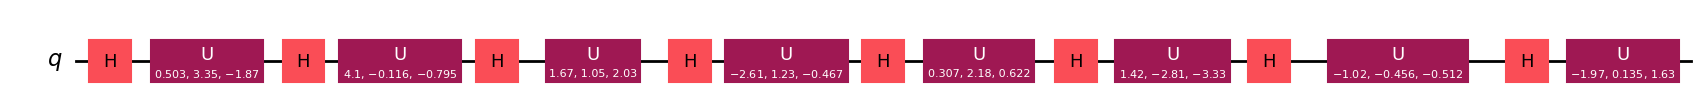

In [31]:
if USE_REUPLOAD:
    print("Circuit re-uploading appris :")
    qc_reupload = create_reupload_circuit(X_train[0], theta_re, omega_re, measure=False)
    display(qc_reupload.draw("mpl"))

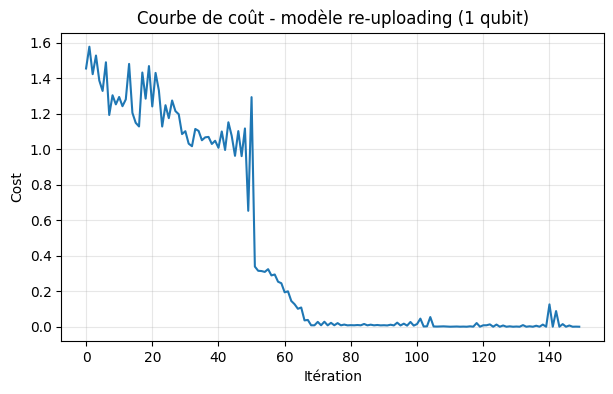

In [32]:
if USE_REUPLOAD:
    plt.figure(figsize=(7, 4))
    plt.plot(reupload_cost_history)
    plt.xlabel("Itération")
    plt.ylabel("Cost")
    plt.title("Courbe de coût - modèle re-uploading (1 qubit)")
    plt.grid(True, alpha=0.3)
    plt.show()

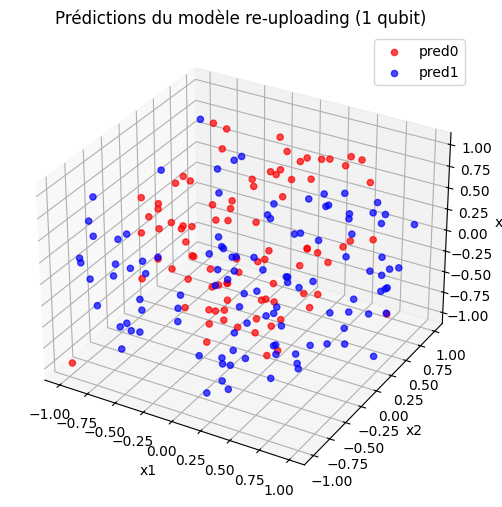

In [33]:
def plot_3d_reupload():
    pred1 = X_test[y_pred_reupload == 1]
    pred0 = X_test[y_pred_reupload == 0]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(pred0[:, 0], pred0[:, 1], pred0[:, 2], color='red', label='pred0', alpha=0.7)
    ax.scatter(pred1[:, 0], pred1[:, 1], pred1[:, 2], color='blue', label='pred1', alpha=0.7)

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('x3')
    ax.set_title('Prédictions du modèle re-uploading (1 qubit)')
    ax.legend()
    plt.show()

if USE_REUPLOAD and N_DIM == 3:
    plot_3d_reupload()

In [34]:
if USE_REUPLOAD:
    print("=== Comparaison rapide ===")
    print(f"VQC classique  ({N_DIM} qubits) : {accuracy * 100:.2f}%")
    print(f"Re-uploading   (1 qubit)  : {reupload_accuracy * 100:.2f}%")

=== Comparaison rapide ===
VQC classique  (3 qubits) : 62.00%
Re-uploading   (1 qubit)  : 67.50%


## AdaBoost sur le modèle re-uploading (1 qubit)

On reprend l'approche de `circuit.ipynb` : plusieurs weak learners quantiques sont entraînés séquentiellement,
puis agrégés par vote pondéré AdaBoost.

In [ ]:
N_ESTIMATORS_REUPLOAD = 5
MAXITER_WEAK_REUPLOAD = MAXITER_REUPLOAD

def reupload_cost_weighted_samples(params, X, y, sample_weights):
    theta = params[:3 * RC_REUPLOAD].reshape(RC_REUPLOAD, 3)
    omega = params[3 * RC_REUPLOAD:].reshape(RC_REUPLOAD, 3)

    circuits = [create_reupload_circuit(x, theta, omega, measure=False) for x in X]
    probs = get_reupload_probs_batch(circuits)

    total_cost = 0.0
    for i, y_target in enumerate(y):
        p0, p1 = probs[i]
        y_expected = (1.0, 0.0) if y_target == 0 else (0.0, 1.0)
        total_cost += sample_weights[i] * ((p0 - y_expected[0])**2 + (p1 - y_expected[1])**2)

    return 0.5 * total_cost / np.sum(sample_weights)

def optimize_reupload_weak_learner(X, y, sample_weights, seed):
    rng = np.random.default_rng(seed)
    init = rng.uniform(-np.pi, np.pi, size=6 * RC_REUPLOAD)

    res = minimize(
        reupload_cost_weighted_samples,
        init,
        args=(X, y, sample_weights),
        method="COBYLA",
        options={"maxiter": MAXITER_WEAK_REUPLOAD},
    )

    theta = res.x[:3 * RC_REUPLOAD].reshape(RC_REUPLOAD, 3)
    omega = res.x[3 * RC_REUPLOAD:].reshape(RC_REUPLOAD, 3)
    return theta, omega, res.fun

def train_adaboost_reupload(X_train, y_train, n_estimators=N_ESTIMATORS_REUPLOAD):
    n = len(y_train)
    weights = np.ones(n) / n
    estimators = []

    for i in range(n_estimators):
        theta, omega, cost = optimize_reupload_weak_learner(
            X_train, y_train, weights, seed=SEED + 100 + i
        )

        y_pred = predict_reupload_batch(X_train, theta, omega)
        incorrect = (y_pred != y_train).astype(float)
        eps = np.dot(weights, incorrect)
        eps = np.clip(eps, 1e-10, 1 - 1e-10)

        alpha = 0.5 * np.log((1 - eps) / eps)

        y_signed = np.where(y_train == 0, -1.0, 1.0)
        h_signed = np.where(y_pred == 0, -1.0, 1.0)
        weights *= np.exp(-alpha * y_signed * h_signed)
        weights /= np.sum(weights)

        estimators.append((theta, omega, alpha))
        print(f"round {i + 1:02d} | cost={cost:.4f} eps={eps:.4f} alpha={alpha:.4f}")

    return estimators

def predict_adaboost_reupload(X, estimators):
    scores = np.zeros(len(X))
    for theta, omega, alpha in estimators:
        h_signed = np.where(predict_reupload_batch(X, theta, omega) == 0, -1.0, 1.0)
        scores += alpha * h_signed
    return np.where(scores >= 0, 1, 0)

def evaluate_adaboost_reupload(X, y, estimators, positive_label=1):
    y_pred = predict_adaboost_reupload(X, estimators)
    metrics = evaluate_binary_predictions(y, y_pred, positive_label=positive_label)
    metrics["y_pred"] = y_pred
    return metrics

if USE_REUPLOAD:
    print("Entraînement AdaBoost (base learner: re-uploading 1 qubit)...")
    estimators_reupload_boost = train_adaboost_reupload(
        X_train, y_train, n_estimators=N_ESTIMATORS_REUPLOAD
    )
    metrics_reupload_boost = evaluate_adaboost_reupload(X_test, y_test, estimators_reupload_boost)
    y_pred_reupload_boost = metrics_reupload_boost["y_pred"]
    reupload_boost_accuracy = metrics_reupload_boost["accuracy"]
    print(
        f"AdaBoost re-uploading | precision={metrics_reupload_boost['precision']:.4f} "
        f"recall={metrics_reupload_boost['recall']:.4f} accuracy={reupload_boost_accuracy:.4f}"
    )
else:
    estimators_reupload_boost = None
    metrics_reupload_boost = None
    y_pred_reupload_boost = None
    reupload_boost_accuracy = None

Entraînement AdaBoost (base learner: re-uploading 1 qubit)...
round 01 | cost=0.2016 eps=0.2913 alpha=0.4447
round 02 | cost=0.1741 eps=0.2455 alpha=0.5614
round 03 | cost=0.1859 eps=0.2643 alpha=0.5120
round 04 | cost=0.1681 eps=0.2383 alpha=0.5809
round 05 | cost=0.1787 eps=0.2404 alpha=0.5753
AdaBoost re-uploading | precision=0.9176 recall=0.7800 accuracy=0.8550


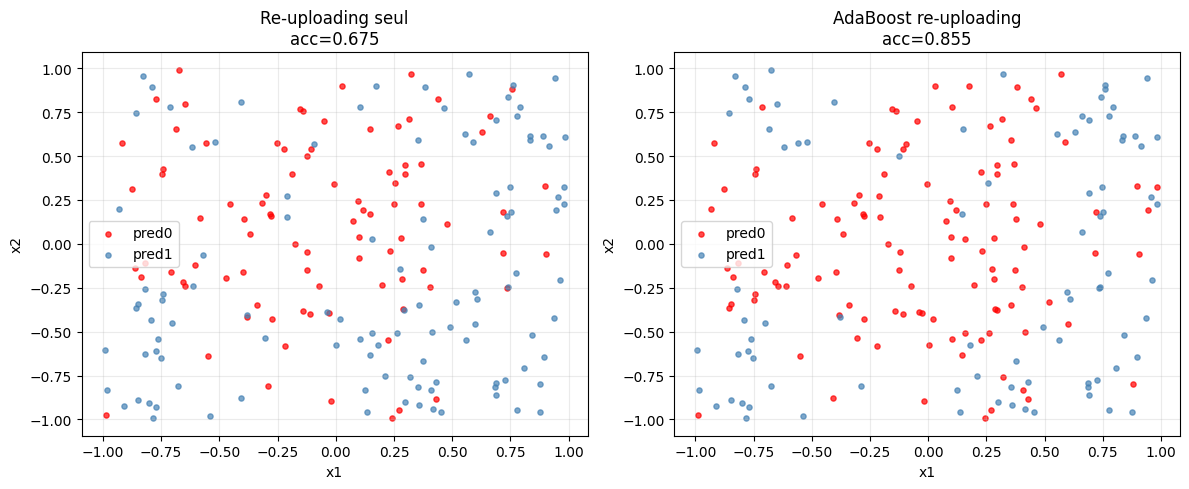

In [ ]:
if USE_REUPLOAD:
    if N_DIM < 2:
        raise ValueError("N_DIM doit etre >= 2 pour la visualisation comparee")

    plots = [
        (y_pred_reupload, f"Re-uploading seul\nacc={reupload_accuracy:.3f}"),
        (y_pred_reupload_boost, f"AdaBoost re-uploading\nacc={reupload_boost_accuracy:.3f}"),
    ]

    # Validation simple pour eviter les erreurs silencieuses de dimensions.
    for pred, _ in plots:
        if pred is None or len(pred) != len(X_test):
            raise ValueError("Chaque vecteur de prediction doit avoir la meme longueur que X_test")

    fig, axes = plt.subplots(1, len(plots), figsize=(12, 5), squeeze=False)
    axes = axes.ravel()

    x0, x1 = 0, 1
    classes = [0, 1]
    colors = {0: "red", 1: "steelblue"}

    for ax, (pred, title) in zip(axes, plots):
        for cls in classes:
            mask = pred == cls
            ax.scatter(
                X_test[mask, x0],
                X_test[mask, x1],
                c=colors[cls],
                s=14,
                alpha=0.7,
                label=f"pred{cls}",
            )

        ax.set_xlabel(f"x{x0 + 1}")
        ax.set_ylabel(f"x{x1 + 1}")
        ax.grid(True, alpha=0.25)
        ax.set_title(title)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [37]:
if USE_REUPLOAD:
    print("=== Comparaison finale ===")
    print(f"VQC classique            ({N_DIM} qubits) : {accuracy * 100:.2f}%")
    print(f"Re-uploading             (1 qubit)  : {reupload_accuracy * 100:.2f}%")
    print(f"AdaBoost + re-uploading  (1 qubit)  : {reupload_boost_accuracy * 100:.2f}%")

    gain = (reupload_boost_accuracy - reupload_accuracy) * 100
    print(f"Gain AdaBoost vs re-uploading seul : {gain:+.2f} points")

=== Comparaison finale ===
VQC classique            (3 qubits) : 62.00%
Re-uploading             (1 qubit)  : 67.50%
AdaBoost + re-uploading  (1 qubit)  : 85.50%
Gain AdaBoost vs re-uploading seul : +18.00 points
